In [1]:
# Run this once if these libraries are not already installed:
# !pip install pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [4]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Cannot parse header or footer so it will be ignored",
    category=UserWarning,
    module="openpyxl.worksheet.header_footer"
)

In [5]:
file_path = Path('data') / 'Sample - Superstore dataset.xlsx'

orders = pd.read_excel(file_path, sheet_name='Orders')
returns = pd.read_excel(file_path, sheet_name='Returns')
people = pd.read_excel(file_path, sheet_name='People')

print(f'Orders shape: {orders.shape}')
print(f'Returns shape: {returns.shape}')
orders.head()

Orders shape: (9994, 21)
Returns shape: (800, 2)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [6]:
orders.info()

print('Missing values:')
display(orders.isna().sum().sort_values(ascending=False).to_frame('Missing values'))
print(f'Duplicate rows: {orders.duplicated().sum():,}')

display(orders[['Sales', 'Quantity', 'Discount', 'Profit']].describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

,Missing values
Postal Code,11
Row ID,0
Discount,0
Quantity,0
Sales,0
Product Name,0
Sub-Category,0
Category,0
Product ID,0
Region,0


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"


In [7]:
# Create useful date fields and add a return flag.
df = orders.copy()
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# One order can appear multiple times in the Returns sheet; retain each order ID only once.
returned_ids = set(returns.loc[returns['Returned'].eq('Yes'), 'Order ID'])
df['Returned'] = df['Order ID'].isin(returned_ids)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Year-Month,Shipping Days,Returned
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2018,November,2018-11,3,False
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2018,November,2018-11,3,False
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2018,June,2018-06,4,False
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2017,October,2017-10,7,False
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2017,October,2017-10,7,False


In [8]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales
unique_orders = df['Order ID'].nunique()
returned_orders = df.loc[df['Returned'], 'Order ID'].nunique()

summary = pd.DataFrame({
    'Metric': ['Total Sales', 'Total Profit', 'Profit Margin', 'Unique Orders', 'Returned Orders', 'Return Rate'],
    'Value': [f'${total_sales:,.2f}', f'${total_profit:,.2f}', f'{profit_margin:.2%}',
              f'{unique_orders:,}', f'{returned_orders:,}', f'{returned_orders / unique_orders:.2%}']
})
display(summary)

,Metric,Value
0,Total Sales,"$2,297,200.86"
1,Total Profit,"$286,397.02"
2,Profit Margin,12.47%
3,Unique Orders,"5,009"
4,Returned Orders,296
5,Return Rate,5.91%


,Sales,Profit
Category,,
Technology,"$836,154.03","$145,454.95"
Furniture,"$741,999.80","$18,451.27"
Office Supplies,"$719,047.03","$122,490.80"


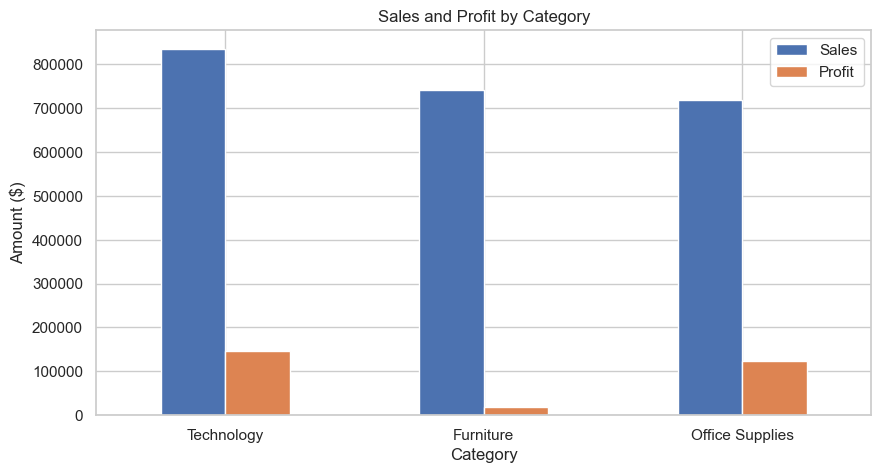

In [9]:
category_summary = (df.groupby('Category')[['Sales', 'Profit']]
                    .sum().sort_values('Sales', ascending=False))
display(category_summary.style.format({'Sales': '${:,.2f}', 'Profit': '${:,.2f}'}))

category_summary.plot(kind='bar', figsize=(10, 5))
plt.title('Sales and Profit by Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

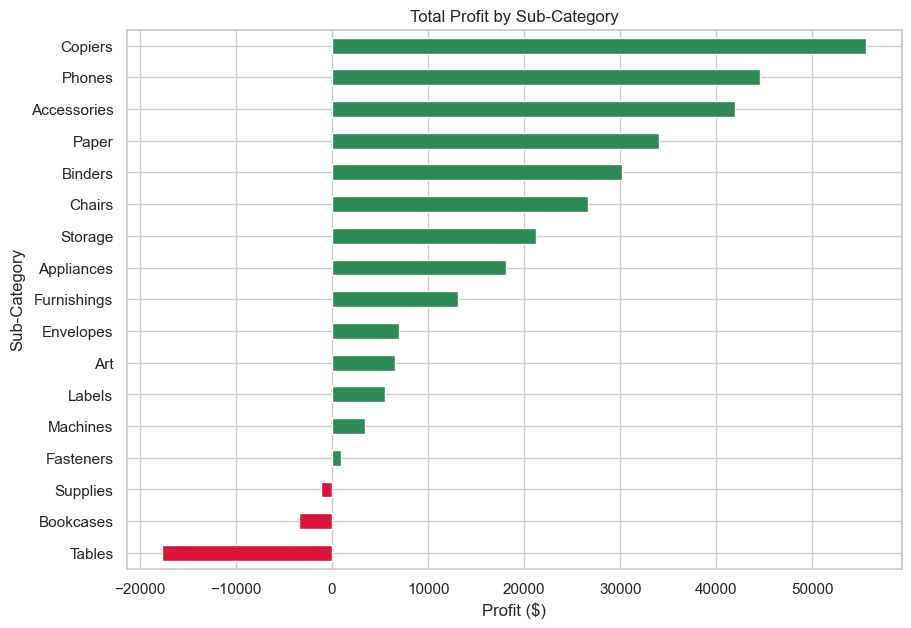

Loss-making sub-categories:


,Total Profit
Sub-Category,
Tables,"$-17,725.48"
Bookcases,"$-3,472.56"
Supplies,"$-1,189.10"


In [10]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
plt.figure(figsize=(10, 7))
colors = ['crimson' if value < 0 else 'seagreen' for value in subcat_profit]
subcat_profit.plot(kind='barh', color=colors)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.show()

loss_making = subcat_profit[subcat_profit < 0]
print('Loss-making sub-categories:')
display(loss_making.to_frame('Total Profit').style.format('${:,.2f}'))

Segment,Consumer,Corporate,Home Office
Region,,,
Central,"$252,031.43","$157,995.81","$91,212.64"
East,"$350,908.17","$200,409.35","$127,463.73"
South,"$195,580.97","$121,885.93","$74,255.00"
West,"$362,880.77","$225,855.27","$136,721.78"


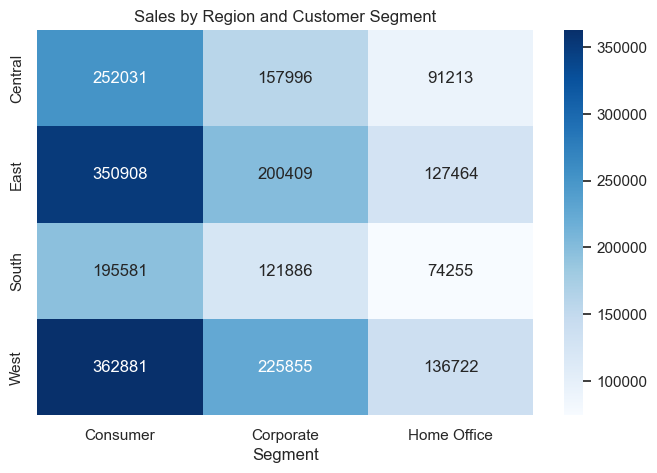

,Total Profit
Region,
West,"$108,418.45"
East,"$91,522.78"
South,"$46,749.43"
Central,"$39,706.36"


In [11]:
region_segment = df.pivot_table(index='Region', columns='Segment', values='Sales', aggfunc='sum')
display(region_segment.style.format('${:,.2f}'))

plt.figure(figsize=(8, 5))
sns.heatmap(region_segment, annot=True, fmt='.0f', cmap='Blues')
plt.title('Sales by Region and Customer Segment')
plt.ylabel('')
plt.show()

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
display(region_profit.to_frame('Total Profit').style.format('${:,.2f}'))

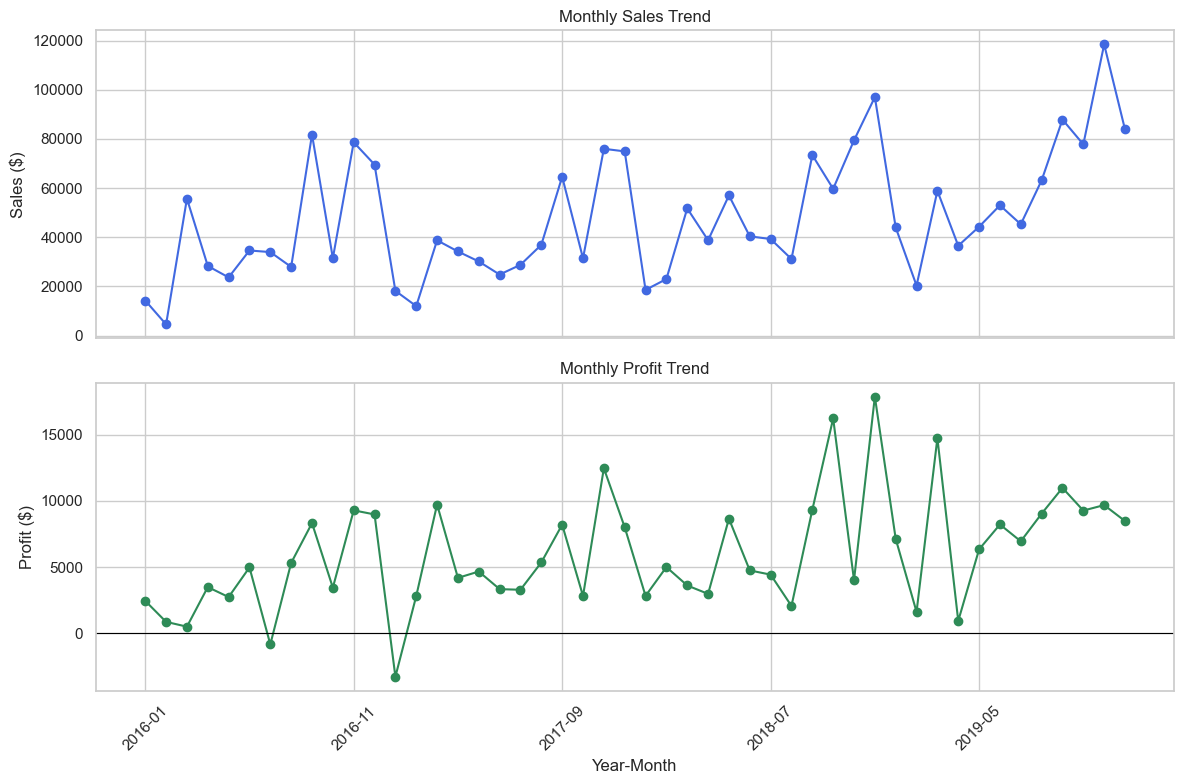

In [12]:
monthly = df.groupby('Year-Month')[['Sales', 'Profit']].sum()
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
monthly['Sales'].plot(ax=axes[0], marker='o', color='royalblue')
axes[0].set_title('Monthly Sales Trend')
axes[0].set_ylabel('Sales ($)')
monthly['Profit'].plot(ax=axes[1], marker='o', color='seagreen')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Monthly Profit Trend')
axes[1].set_ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

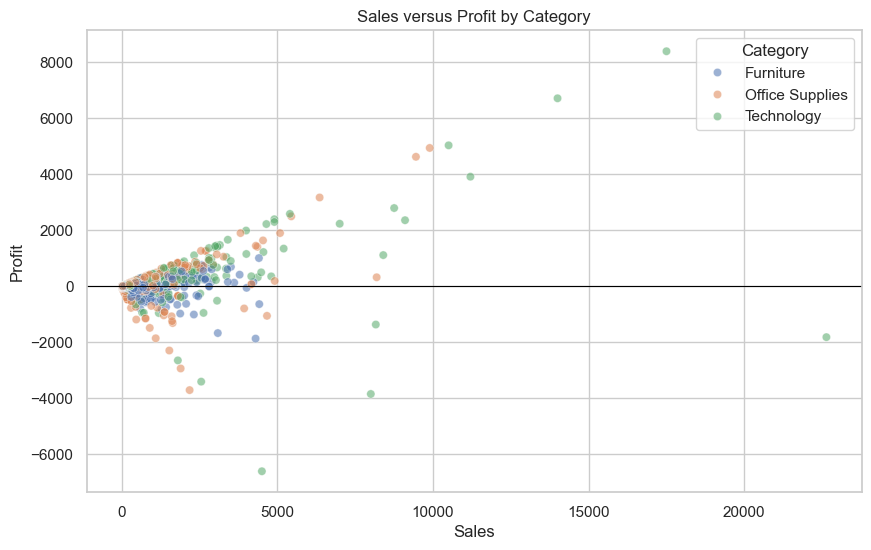

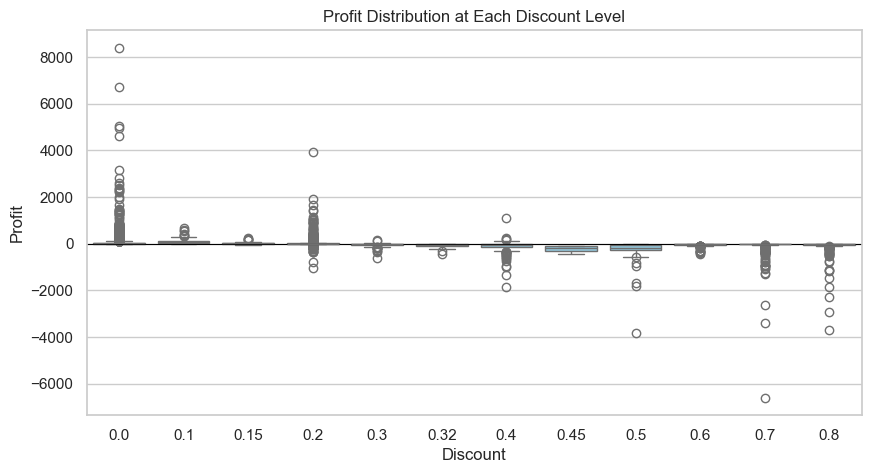

Correlation of numerical variables:


,Sales,Quantity,Discount,Profit,Shipping Days
Sales,1.00,0.20,-0.03,0.48,-0.01
Quantity,0.20,1.00,0.01,0.07,0.02
Discount,-0.03,0.01,1.00,-0.22,0.00
Profit,0.48,0.07,-0.22,1.00,-0.00
Shipping Days,-0.01,0.02,0.00,-0.00,1.00


In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.55)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Sales versus Profit by Category')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Discount', y='Profit', color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Profit Distribution at Each Discount Level')
plt.show()

print('Correlation of numerical variables:')
display(df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']].corr().round(2))

,Returned,Order_Lines,Unique_Orders,Sales,Profit
0,False,9194,4713,"$2,116,696.58","$263,164.66"
1,True,800,296,"$180,504.28","$23,232.36"


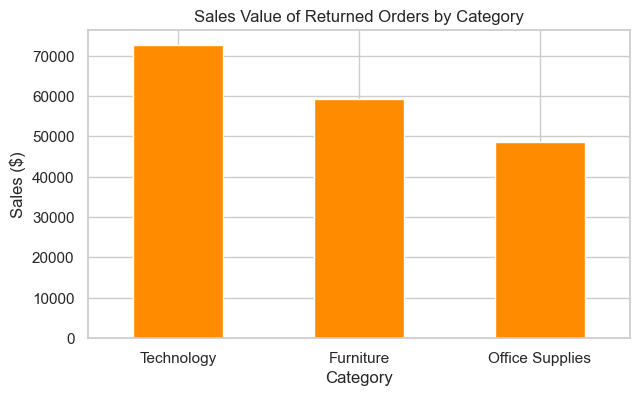

In [14]:
return_analysis = df.groupby('Returned').agg(
    Order_Lines=('Order ID', 'size'),
    Unique_Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
display(return_analysis.style.format({'Sales': '${:,.2f}', 'Profit': '${:,.2f}'}))

returned_by_category = df[df['Returned']].groupby('Category')['Sales'].sum().sort_values(ascending=False)
returned_by_category.plot(kind='bar', color='darkorange', figsize=(7, 4))
plt.title('Sales Value of Returned Orders by Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

Sales outlier limits: $-271.71 to $498.93
Sales outliers: 1,167
Profit outliers: 1,881


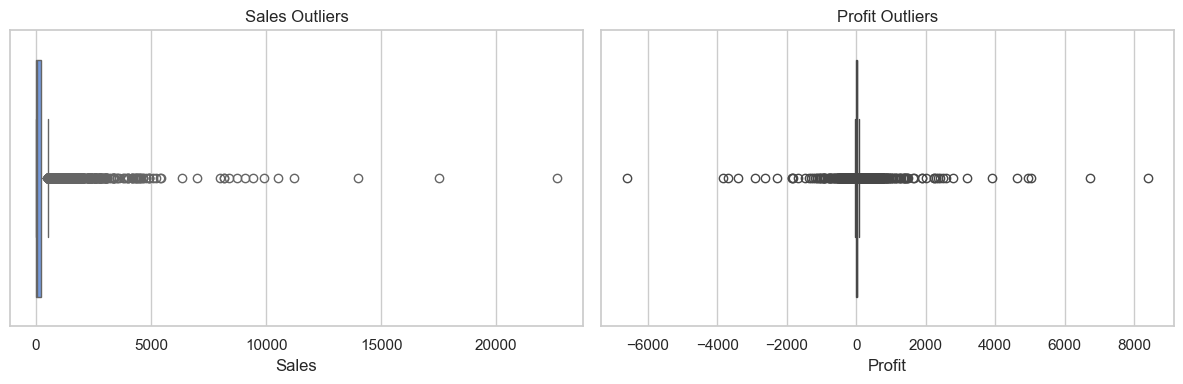

,Order ID,Product Name,Category,Sales,Profit,Discount
2697,CA-2016-145317,Cisco TelePresence System EX90 Videoconferencing Unit,Technology,"$22,638.48","$-1,811.08",50%
6826,CA-2018-118689,Canon imageCLASS 2200 Advanced Copier,Technology,"$17,499.95","$8,399.98",0%
8153,CA-2019-140151,Canon imageCLASS 2200 Advanced Copier,Technology,"$13,999.96","$6,719.98",0%
2623,CA-2019-127180,Canon imageCLASS 2200 Advanced Copier,Technology,"$11,199.97","$3,919.99",20%
4190,CA-2019-166709,Canon imageCLASS 2200 Advanced Copier,Technology,"$10,499.97","$5,039.99",0%
9039,CA-2018-117121,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,"$9,892.74","$4,946.37",0%
4098,CA-2016-116904,Ibico EPK-21 Electric Binding System,Office Supplies,"$9,449.95","$4,630.48",0%
4277,US-2018-107440,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,"$9,099.93","$2,365.98",0%
8488,CA-2018-158841,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",Technology,"$8,749.95","$2,799.98",0%
6425,CA-2018-143714,Canon imageCLASS 2200 Advanced Copier,Technology,"$8,399.98","$1,120.00",40%


In [15]:
def find_iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (series < lower_bound) | (series > upper_bound)
    return mask, lower_bound, upper_bound

sales_outlier_mask, sales_lower, sales_upper = find_iqr_outliers(df['Sales'])
profit_outlier_mask, profit_lower, profit_upper = find_iqr_outliers(df['Profit'])

print(f'Sales outlier limits: ${sales_lower:,.2f} to ${sales_upper:,.2f}')
print(f'Sales outliers: {sales_outlier_mask.sum():,}')
print(f'Profit outliers: {profit_outlier_mask.sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Sales'], ax=axes[0], color='cornflowerblue')
axes[0].set_title('Sales Outliers')
sns.boxplot(x=df['Profit'], ax=axes[1], color='mediumseagreen')
axes[1].set_title('Profit Outliers')
plt.tight_layout()
plt.show()

sales_outliers = df.loc[sales_outlier_mask, ['Order ID', 'Product Name', 'Category', 'Sales', 'Profit', 'Discount']].sort_values('Sales', ascending=False)
display(sales_outliers.head(10).style.format({'Sales': '${:,.2f}', 'Profit': '${:,.2f}', 'Discount': '{:.0%}'}))

# Final Findings and Business Recommendations

## Key Findings

- The dataset contains 9,994 order records.
- Sales and profit differ across categories, sub-categories, regions, and customer segments.
- Some sub-categories generate negative profit and should be reviewed.
- Higher discounts may reduce profit for some orders.
- Returned orders should be analysed because they can affect business revenue.
- Sales and profit outliers were detected using the IQR method.

## Business Recommendations

1. Reduce excessive discounts on loss-making products.
2. Focus marketing efforts on profitable categories and regions.
3. Review sub-categories with negative profit.
4. Track returned orders to identify product or service problems.
5. Investigate high-value outlier orders.